# HCE + Cell2Sentence — v3 (Single-Label, Corrected HCE)

**Key design decisions vs v2:**

| | v1 | v2 | **v3 (this notebook)** |
|---|---|---|---|
| Label scheme | Single-label | Option A (multi-level) | **Single-label** |
| HCE implementation | Buggy (child→parent) | Corrected | **Corrected** |
| Epochs | 10 | 5 | **10** |
| LR | 1e-4 | 2e-4 | **1e-4** |
| min_cells_per_type | 20 | 20 | **100** |
| AMP/GradScaler | No | Yes (buggy) | **No** |

**Why single-label fixes the 0% recall problem:**

Option A introduces label ambiguity for "collision" classes — cell types that appear as both a
finest-level annotation AND as an ancestor of a finer subtype (e.g. AT2 is both a leaf class and
the parent of AT2 proliferating). Option A randomly labels AT2-proliferating cells as "AT2" at
training time, making it impossible for the model to distinguish "AT2" cells from the AT2 lineage.

Single-label always uses the finest annotation. The corrected HCE reachability matrix still gives
partial credit when predicting an ancestor class, preserving the hierarchy benefit.

## 1. Imports

In [1]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import scanpy as sc
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import scipy.sparse as sp
import h5py

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))
from cell2sentence.hce_trainer import build_reachability_matrix_from_ontology

warnings.filterwarnings("ignore")
print("=" * 60)
print("  IMPORTS OK")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {torch.cuda.is_available()} | device count: {torch.cuda.device_count()}")
print("=" * 60)

/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/c2s-justin/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  IMPORTS OK
  PyTorch  : 2.10.0+cu128
  CUDA     : True | device count: 1


## 2. Configuration

In [2]:
print("=" * 60)
print("  STEP 1/9 - Configuration")
print("=" * 60)

LUNG_H5AD_PATH  = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad'
OUT_DIR         = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_v3_results'
BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.pt')
C2S_MODEL_NAME  = 'vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation'

ANN_COL              = 'ann_finest_level'
LEVEL_COLS           = ['ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5']
TOP_K_GENES          = 100
MAX_CELLS_PER_TYPE   = 1000
MIN_CELLS_PER_TYPE   = 100   # raised from 20 — removes statistically unreliable classes
TEST_FRAC            = 0.15
VAL_FRAC             = 0.10
BATCH_SIZE           = 8
N_EPOCHS             = 10
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-2
WARMUP_STEPS         = 100
MAX_SEQ_LEN          = 512
SEED                 = 42

os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"  Output dir         : {OUT_DIR}")
print(f"  C2S model          : {C2S_MODEL_NAME}")
print(f"  Device             : {device}")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Epochs             : {N_EPOCHS}")
print(f"  LR                 : {LEARNING_RATE}")
print(f"  Top-k genes        : {TOP_K_GENES}")
print(f"  Max seq len        : {MAX_SEQ_LEN}")
print(f"  Max cells/type     : {MAX_CELLS_PER_TYPE}")
print(f"  Min cells/type     : {MIN_CELLS_PER_TYPE}  (raised from 20)")
print("[OK] Config ready")

  STEP 1/9 - Configuration
  Output dir         : /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_v3_results
  C2S model          : vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
  Device             : cuda
  Batch size         : 8
  Epochs             : 10
  LR                 : 0.0001
  Top-k genes        : 100
  Max seq len        : 512
  Max cells/type     : 1000
  Min cells/type     : 100  (raised from 20)
[OK] Config ready


## 3. Load and Balance Dataset

In [4]:
print("=" * 60)
print("  STEP 2/9 - Load dataset")
print("=" * 60)
t0 = time.time()
print(f"  Reading: {LUNG_H5AD_PATH}")
adata = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')
print(f"  Raw shape        : {adata.shape}  (cells x genes)")

level_columns = [c for c in LEVEL_COLS if c in adata.obs.columns]
print(f"  Annotation levels: {level_columns}")
print(f"  Finest-level col : {ANN_COL}")

def is_valid_annotation(value):
    if pd.isna(value): return False
    s = str(value).strip().lower()
    return s not in ('', 'nan', 'none', 'unknown', 'na', 'n/a')

# Filter and cap
valid_mask = adata.obs[ANN_COL].apply(is_valid_annotation)
obs_b = adata.obs[valid_mask].copy()
valid_row_indices = np.where(valid_mask.values)[0]
print(f"  Cells with valid '{ANN_COL}': {len(obs_b):,}")

labels_valid = obs_b[ANN_COL].astype(str).values
sampled_pos = []
for lbl in np.unique(labels_valid):
    pos = np.where(labels_valid == lbl)[0]
    n_keep = min(len(pos), MAX_CELLS_PER_TYPE)
    if len(pos) > n_keep:
        pos = np.random.choice(pos, size=n_keep, replace=False)
    sampled_pos.extend(pos.tolist())

sampled_pos = np.sort(np.array(sampled_pos, dtype=np.int64))
obs_b = obs_b.iloc[sampled_pos].copy()
valid_row_indices = valid_row_indices[sampled_pos]

# Apply minimum cells per type filter
counts_after_cap = obs_b[ANN_COL].astype(str).value_counts()
keep_types = counts_after_cap[counts_after_cap >= MIN_CELLS_PER_TYPE].index
dropped_types = counts_after_cap[counts_after_cap < MIN_CELLS_PER_TYPE]
if len(dropped_types) > 0:
    print(f"\n  Dropping {len(dropped_types)} class(es) with < {MIN_CELLS_PER_TYPE} cells:")
    for ct, n in dropped_types.items():
        print(f"    - {ct}: {n} cells")
    keep_mask = obs_b[ANN_COL].isin(keep_types)
    obs_b = obs_b[keep_mask].copy()
    valid_row_indices = valid_row_indices[keep_mask.values]

counts_final = obs_b[ANN_COL].astype(str).value_counts()
print(f"\n  Cells after cap + min filter : {len(obs_b):,}")
print(f"  Cell types                   : {counts_final.shape[0]}")
print(f"  Max cells in any type        : {int(counts_final.max())}")

counts_final.to_csv(os.path.join(OUT_DIR, 'balanced_counts.csv'), header=['count'])
print(f"  Elapsed: {time.time()-t0:.1f}s")
print("[OK] Dataset loaded and balanced")

  STEP 2/9 - Load dataset
  Reading: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad
  Raw shape        : (2282447, 55329)  (cells x genes)
  Annotation levels: ['ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5']
  Finest-level col : ann_finest_level
  Cells with valid 'ann_finest_level': 1,659,134

  Dropping 2 class(es) with < 100 cells:
    - Hematopoietic stem cells: 61 cells
    - Lymphatic EC proliferating: 28 cells

  Cells after cap + min filter : 57,522
  Cell types                   : 59
  Max cells in any type        : 1000
  Elapsed: 27.5s
[OK] Dataset loaded and balanced


## 4. Build Cell Type Hierarchy

In [5]:
print("=" * 60)
print("  STEP 3/9 - Build cell-type hierarchy")
print("=" * 60)
t0 = time.time()

# Build parent->child ontology from annotation level columns.
# No deduplication/renaming needed — single-label training means there is
# no ambiguity when a class appears as both a leaf and an interior node.
ontology_dict = {}
cols_ordered = level_columns + [ANN_COL]
for k in range(1, len(cols_ordered)):
    parent_col, child_col = cols_ordered[k-1], cols_ordered[k]
    if parent_col not in obs_b.columns or child_col not in obs_b.columns:
        continue
    pairs = obs_b[[parent_col, child_col]].dropna().drop_duplicates()
    for _, row in pairs.iterrows():
        p, ch = str(row[parent_col]), str(row[child_col])
        if is_valid_annotation(p) and is_valid_annotation(ch):
            if ch not in ontology_dict:
                ontology_dict[ch] = p

# Root nodes
root_col = cols_ordered[0]
if root_col in obs_b.columns:
    for val in obs_b[root_col].dropna().unique():
        if is_valid_annotation(val) and str(val) not in ontology_dict:
            ontology_dict[str(val)] = None

print(f"  Finest-level cell types : {obs_b[ANN_COL].nunique()}")
print(f"  Ontology entries        : {len(ontology_dict)}")
print(f"  Elapsed                 : {time.time()-t0:.1f}s")

# Save ontology
pd.DataFrame(list(ontology_dict.items()), columns=['child', 'parent']).to_csv(
    os.path.join(OUT_DIR, 'ontology.csv'), index=False)
print("[OK] Hierarchy built (no collision renaming)")

  STEP 3/9 - Build cell-type hierarchy
  Finest-level cell types : 59
  Ontology entries        : 91
  Elapsed                 : 0.1s
[OK] Hierarchy built (no collision renaming)


## 5. Cell-to-Text Conversion (Single-Label)

In [6]:
print("=" * 60)
print("  STEP 4/9 - Cell-to-text conversion")
print("=" * 60)
t0 = time.time()

def cell_to_text_backed(h5_X, row_idx, gene_names, top_k=100):
    """Stream one row from backed CSR X and return top-k gene text."""
    indptr = h5_X['indptr']
    start, end = int(indptr[row_idx]), int(indptr[row_idx + 1])
    if start == end:
        return ""
    vals = h5_X['data'][start:end]
    cols = h5_X['indices'][start:end]
    if len(vals) == 0:
        return ""
    if len(vals) <= top_k:
        order = np.argsort(vals)[::-1]
    else:
        order = np.argpartition(vals, -top_k)[-top_k:]
        order = order[np.argsort(vals[order])[::-1]]
    return " ".join(str(gene_names[cols[j]]) for j in order if vals[j] > 0)

print(f"  Converting {len(valid_row_indices):,} cells to top-{TOP_K_GENES}-gene text ...")
with h5py.File(LUNG_H5AD_PATH, 'r') as _h5:
    h5_X = _h5['X']
    gene_names = np.array(adata.var_names)
    all_texts = [
        cell_to_text_backed(h5_X, int(valid_row_indices[i]), gene_names, TOP_K_GENES)
        for i in tqdm(range(len(valid_row_indices)), desc="  cell->text", leave=False)
    ]

keep_idx   = [i for i, t in enumerate(all_texts) if t.strip()]
cell_texts = [all_texts[i] for i in keep_idx]
# Single-label: each cell gets exactly its finest-level annotation
cell_labels = obs_b[ANN_COL].iloc[keep_idx].astype(str).values

print(f"  Non-empty cells kept : {len(cell_texts):,}  (dropped {len(obs_b) - len(cell_texts)})")
print(f"  Sample (first 80ch)  : {cell_texts[0][:80]} ...")
print(f"  Label scheme         : SINGLE-LABEL (finest level only — no Option A)")
print(f"  Elapsed: {time.time()-t0:.1f}s")
print("[OK] Cell texts ready")

  STEP 4/9 - Cell-to-text conversion
  Converting 57,522 cells to top-100-gene text ...


  Non-empty cells kept : 57,522  (dropped 0)
  Sample (first 80ch)  : ENSG00000186847 ENSG00000196754 ENSG00000198804 ENSG00000205420 ENSG00000140988  ...
  Label scheme         : SINGLE-LABEL (finest level only — no Option A)
  Elapsed: 63.6s
[OK] Cell texts ready


## 6. Class Vocabulary, Dataset, and Splits

In [7]:
print("=" * 60)
print("  STEP 5/9 - Tokenizer, class vocab, Dataset, splits")
print("=" * 60)
t0 = time.time()

print("  Loading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(C2S_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"  Tokenizer vocab size : {tokenizer.vocab_size:,}")

# Class vocabulary = leaf classes (finest level) + ancestor nodes from ontology.
# Ancestors are included so the HCE reachability matrix can credit predictions
# at coarser levels even though training always uses the finest label.
leaf_classes_set = set(cell_labels)

# Collect all nodes from ontology
all_nodes = set()
for child, parent in ontology_dict.items():
    all_nodes.add(child)
    if parent:
        all_nodes.add(parent)
all_nodes |= leaf_classes_set

class_names  = sorted(all_nodes)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
n_classes    = len(class_names)

leaf_classes = sorted(leaf_classes_set)
leaf_indices = [class_to_idx[c] for c in leaf_classes if c in class_to_idx]
leaf_index_set = set(leaf_indices)
n_coarser = n_classes - len(leaf_classes)

print(f"  Total classes (leaf + ancestors) : {n_classes}")
print(f"  Leaf classes                     : {len(leaf_classes)}")
print(f"  Ancestor-only nodes              : {n_coarser}")

# Encode labels (single index per cell — always finest level)
labels_encoded = np.array([class_to_idx[cell_labels[i]] for i in range(len(cell_labels))], dtype=int)

class CellTextDataset(Dataset):
    '''Single-label dataset. Each cell has exactly one label (finest level).'''
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# Stratified split
idx_all = np.arange(len(cell_texts))
idx_tv, idx_test   = train_test_split(idx_all, test_size=TEST_FRAC,              stratify=labels_encoded,          random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv,  test_size=VAL_FRAC/(1-TEST_FRAC), stratify=labels_encoded[idx_tv],  random_state=SEED)

train_labels = labels_encoded[idx_train]
val_labels   = labels_encoded[idx_val]
test_labels  = labels_encoded[idx_test]

print(f"  Train : {len(idx_train):,}")
print(f"  Val   : {len(idx_val):,}")
print(f"  Test  : {len(idx_test):,}")

train_ds = CellTextDataset([cell_texts[i] for i in idx_train], train_labels, tokenizer, MAX_SEQ_LEN)
val_ds   = CellTextDataset([cell_texts[i] for i in idx_val],   val_labels,   tokenizer, MAX_SEQ_LEN)
test_ds  = CellTextDataset([cell_texts[i] for i in idx_test],  test_labels,  tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train batches : {len(train_loader)}")
print(f"  Elapsed       : {time.time()-t0:.1f}s")
print("[OK] Datasets and DataLoaders ready")

  STEP 5/9 - Tokenizer, class vocab, Dataset, splits
  Loading tokenizer ...
  Tokenizer vocab size : 50,254
  Total classes (leaf + ancestors) : 91
  Leaf classes                     : 59
  Ancestor-only nodes              : 32
  Train : 43,140
  Val   : 5,753
  Test  : 8,629
  Train batches : 5393
  Elapsed       : 0.6s
[OK] Datasets and DataLoaders ready


## 7. Model Architecture

In [8]:
print("=" * 60)
print("  STEP 6/9 - Build C2S encoder model")
print("=" * 60)
t0 = time.time()

print(f"  Loading C2S encoder: {C2S_MODEL_NAME} ...")
c2s_model   = AutoModel.from_pretrained(C2S_MODEL_NAME)
c2s_model.gradient_checkpointing_enable()
hidden_size = c2s_model.config.hidden_size
n_params    = sum(p.numel() for p in c2s_model.parameters()) / 1e6

class C2SClassifier(nn.Module):
    def __init__(self, encoder, hidden_size, num_classes):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out         = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state                      # (B, T, H)
        # Last non-padding token — correct pooling for causal/decoder-only LM
        seq_len     = attention_mask.sum(dim=1) - 1
        last_token  = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_len]
        return self.head(self.dropout(last_token))               # (B, n_classes)

model = C2SClassifier(c2s_model, hidden_size, n_classes).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"  Hidden size       : {hidden_size}")
print(f"  Encoder params    : {n_params:.1f}M")
print(f"  Total params      : {total_params:.1f}M  (encoder + head)")
print(f"  Output classes    : {n_classes}  (leaves + ancestors)")
print(f"  Device            : {device}")
print(f"  Elapsed           : {time.time()-t0:.1f}s")
print("[OK] Model ready")

  STEP 6/9 - Build C2S encoder model
  Loading C2S encoder: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation ...


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 601.96it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size       : 1024
  Encoder params    : 353.8M
  Total params      : 353.9M  (encoder + head)
  Output classes    : 91  (leaves + ancestors)
  Device            : cuda
  Elapsed           : 1.1s
[OK] Model ready


## 8. Reachability Matrix and Weighted HCE Loss

In [9]:
print("=" * 60)
print("  STEP 7/9 - HCE reachability matrix + loss + class weights")
print("=" * 60)
t0 = time.time()

print("  Building reachability matrix from ontology ...")
R_np = build_reachability_matrix_from_ontology(ontology_dict, class_names)
reachability_matrix = torch.tensor(R_np, dtype=torch.float32).to(device)

n_ct    = reachability_matrix.shape[0]
diag_ok = torch.allclose(torch.diag(reachability_matrix), torch.ones(n_ct, device=device))
nnz     = int(reachability_matrix.sum().item())
density = nnz / (n_ct * n_ct) * 100
print(f"  Matrix shape : {n_ct} x {n_ct}")
print(f"  Diagonal OK  : {diag_ok}")
print(f"  Non-zeros    : {nnz}  ({density:.1f}% density)")

# Class weights w_i = N / (C * n_i) for leaf classes
# Ancestor nodes get weight proportional to effective descendant count
print("  Computing class weights ...")
train_counts = Counter(train_labels.tolist())
N_train = len(train_labels)
C_obs   = len(train_counts)

class_weights = torch.zeros(n_classes, dtype=torch.float32, device=device)
for idx_ct, count in train_counts.items():
    class_weights[idx_ct] = N_train / (C_obs * count)

ancestor_indices = [i for i in range(n_classes) if i not in leaf_index_set]
for anc_idx in ancestor_indices:
    eff = sum(train_counts.get(j, 0) for j in leaf_indices if R_np[anc_idx, j] > 0)
    if eff > 0:
        class_weights[anc_idx] = N_train / (C_obs * eff)

# Cap extreme weights to prevent rare-class gradient dominance
MAX_WEIGHT = 10.0
class_weights = torch.clamp(class_weights, max=MAX_WEIGHT)
nz_w = (class_weights > 0).sum().item()
w_min = class_weights[class_weights > 0].min().item()
w_max = class_weights[class_weights > 0].max().item()
print(f"  Observed classes  : {nz_w} / {n_classes}")
print(f"  Weight range      : [{w_min:.4f}, {w_max:.4f}]  (capped at {MAX_WEIGHT})")

class HCELoss(nn.Module):
    """
    Corrected Hierarchical Cross-Entropy Loss (paper Eq. 7).
    R[parent, child] = 1  (PARENT->CHILD, with transitive closure)
    s = softmax(logits) @ R.T          (paper Eq. 4)
    L = -w_t * log(s_t + eps)          (paper Eq. 7)
    """
    def __init__(self, R, class_weights=None, eps=1e-8):
        super().__init__()
        self.register_buffer('R', R)
        self.eps = eps
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        probs  = torch.softmax(logits, dim=1)
        s      = torch.clamp(probs @ self.R.T, min=self.eps)
        log_st = torch.log(s)[torch.arange(len(targets), device=targets.device), targets]
        if self.class_weights is not None:
            return -(self.class_weights[targets] * log_st).mean()
        return -log_st.mean()

criterion = HCELoss(reachability_matrix, class_weights).to(device)
print(f"  Elapsed: {time.time()-t0:.1f}s")
print("[OK] HCE loss ready")

  STEP 7/9 - HCE reachability matrix + loss + class weights
  Building reachability matrix from ontology ...
  Matrix shape : 91 x 91
  Diagonal OK  : True
  Non-zeros    : 325  (3.9% density)
  Computing class weights ...
  Observed classes  : 91 / 91
  Weight range      : [0.0444, 2.9844]  (capped at 10.0)
  Elapsed: 0.1s
[OK] HCE loss ready


## 9. Training

In [11]:
print("=" * 60)
print("  STEP 8/9 - Training")
print("=" * 60)
t_start = time.time()

optimizer        = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps      = len(train_loader) * N_EPOCHS
warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_STEPS)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - WARMUP_STEPS)

# No AMP/GradScaler — avoids FP16 gradient error with gradient_checkpointing
leaf_indices_t = torch.tensor(leaf_indices, device=device)
history        = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc   = 0.0
global_step    = 0

print(f"  Epochs        : {N_EPOCHS}")
print(f"  Steps/epoch   : {len(train_loader)}")
print(f"  Total steps   : {total_steps}")
print(f"  Warmup steps  : {WARMUP_STEPS}")

for epoch in range(1, N_EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    running_loss, n_batches = 0.0, 0

    pbar = tqdm(train_loader, desc=f"  Epoch {epoch}/{N_EPOCHS} [train]", leave=True)
    for batch in pbar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if global_step < WARMUP_STEPS:
            warmup_scheduler.step()
        else:
            cosine_scheduler.step()
        global_step += 1

        running_loss += loss.item()
        n_batches    += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    train_loss = running_loss / n_batches

    # Validation — predict among leaf classes only
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"  Epoch {epoch}/{N_EPOCHS} [val]  ", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)
            logits         = model(input_ids, attention_mask)
            val_loss_sum  += criterion(logits, labels_b).item() * len(labels_b)
            leaf_logits    = logits[:, leaf_indices_t]
            preds          = leaf_indices_t[leaf_logits.argmax(dim=1)]
            val_correct   += (preds == labels_b).sum().item()
            val_total     += len(labels_b)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc}, BEST_MODEL_PATH)

    print(f"  Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
          f"{'** BEST **' if improved else ''} | time={time.time()-t_epoch:.0f}s")

print(f"  Training complete in {(time.time()-t_start)/60:.1f} min")
print(f"  Best val accuracy: {best_val_acc:.4f}")
print("[OK] Training done")

  STEP 8/9 - Training
  Epochs        : 10
  Steps/epoch   : 5393
  Total steps   : 53930
  Warmup steps  : 100


  Epoch 1/10 [train]: 100%|██████████| 5393/5393 [1:28:20<00:00,  1.02it/s, loss=2.6122, lr=9.76e-05]


  Epoch 1/10 | train_loss=2.8397 | val_loss=1.3436 | val_acc=0.5409 | ** BEST ** | time=5493s


  Epoch 2/10 [train]: 100%|██████████| 5393/5393 [1:26:22<00:00,  1.04it/s, loss=1.7603, lr=9.06e-05]


  Epoch 2/10 | train_loss=1.1292 | val_loss=0.9630 | val_acc=0.6663 | ** BEST ** | time=5377s


...

  Epoch 8/10 | train_loss=0.4133 | val_loss=0.5999 | val_acc=0.7932 | ** BEST ** | time=5375s


  Epoch 9/10 [train]: 100%|██████████| 5393/5393 [1:26:21<00:00,  1.04it/s, loss=0.2176, lr=2.46e-06]


  Epoch 9/10 | train_loss=0.3518 | val_loss=0.6344 | val_acc=0.7900 |  | time=5371s


  Epoch 10/10 [train]: 100%|██████████| 5393/5393 [1:26:20<00:00,  1.04it/s, loss=0.2590, lr=0.00e+00]


  Epoch 10/10 | train_loss=0.3001 | val_loss=0.6455 | val_acc=0.7947 | ** BEST ** | time=5376s
  Training complete in 898.0 min
  Best val accuracy: 0.7947
[OK] Training done


## 10. Test Set Evaluation

In [12]:
print("=" * 60)
print("  STEP 9/9 - Evaluation on test set")
print("=" * 60)
t0 = time.time()

if os.path.exists(BEST_MODEL_PATH):
    ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"  Loaded best checkpoint (epoch {ckpt.get('epoch','?')}, val_acc={ckpt.get('val_acc',0):.4f})")
else:
    print("  WARNING: No checkpoint found, using current model weights")

model.eval()
test_preds_all, test_trues_all = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="  Evaluating test set", leave=True):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)
        logits         = model(input_ids, attention_mask)
        leaf_logits    = logits[:, leaf_indices_t]
        preds          = leaf_indices_t[leaf_logits.argmax(dim=1)]
        test_preds_all.extend(preds.cpu().numpy())
        test_trues_all.extend(labels_b.cpu().numpy())

test_preds_all = np.array(test_preds_all)
test_trues_all = np.array(test_trues_all)

test_acc = accuracy_score(test_trues_all, test_preds_all)
unique_test = np.unique(test_trues_all)
prec_pc, rec_pc, f1_pc, sup_pc = precision_recall_fscore_support(
    test_trues_all, test_preds_all, labels=unique_test, zero_division=0)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    test_trues_all, test_preds_all, labels=unique_test, average='macro', zero_division=0)

per_class = pd.DataFrame({
    'cell_type': [class_names[i] for i in unique_test],
    'precision': prec_pc,
    'recall':    rec_pc,
    'f1':        f1_pc,
    'support':   sup_pc,
}).sort_values('f1', ascending=False).reset_index(drop=True)

per_class.drop(columns=['support']).to_csv(os.path.join(OUT_DIR, 'per_class_metrics.csv'), index=False)

print(f"  Test samples  : {len(test_trues_all):,}")
print(f"  Test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro F1      : {f1_m:.4f}")
print(f"  Macro Prec    : {prec_m:.4f}")
print(f"  Macro Rec     : {rec_m:.4f}")
print(f"  Elapsed       : {time.time()-t0:.1f}s")

zero_recall = per_class[per_class['recall'] == 0.0]
if len(zero_recall) > 0:
    print(f"\n  Classes with 0% recall ({len(zero_recall)}):")
    for _, row in zero_recall.iterrows():
        print(f"    - {row['cell_type']}")
else:
    print("\n  No classes with 0% recall!")

print("\n  Top 10 by F1:")
print(per_class[['cell_type', 'precision', 'recall', 'f1']].head(10).to_string(index=False))
print("[OK] Evaluation complete")

  STEP 9/9 - Evaluation on test set
  Loaded best checkpoint (epoch 10, val_acc=0.7947)


  Evaluating test set: 100%|██████████| 1079/1079 [04:43<00:00,  3.81it/s]

  Test samples  : 8,629
  Test accuracy : 0.7868  (78.68%)
  Macro F1      : 0.7716
  Macro Prec    : 0.7623
  Macro Rec     : 0.7891
  Elapsed       : 286.0s

  Classes with 0% recall (3):
    - Alveolar macrophages
    - AT2
    - Smooth muscle

  Top 10 by F1:
             cell_type  precision   recall       f1
            SMG mucous   0.966216 0.953333 0.959732
          Plasma cells   0.947712 0.966667 0.957096
 T cells proliferating   0.928105 0.946667 0.937294
              Ionocyte   0.964029 0.893333 0.927336
 Goblet (subsegmental)   0.899371 0.953333 0.925566
           Mesothelium   0.904459 0.946667 0.925081
      Plasmacytoid DCs   0.950704 0.900000 0.924658
            Mast cells   0.937931 0.906667 0.922034
SMG serous (bronchial)   0.920000 0.920000 0.920000
    SMG serous (nasal)   0.911565 0.893333 0.902357
[OK] Evaluation complete


## 11. Visualisation

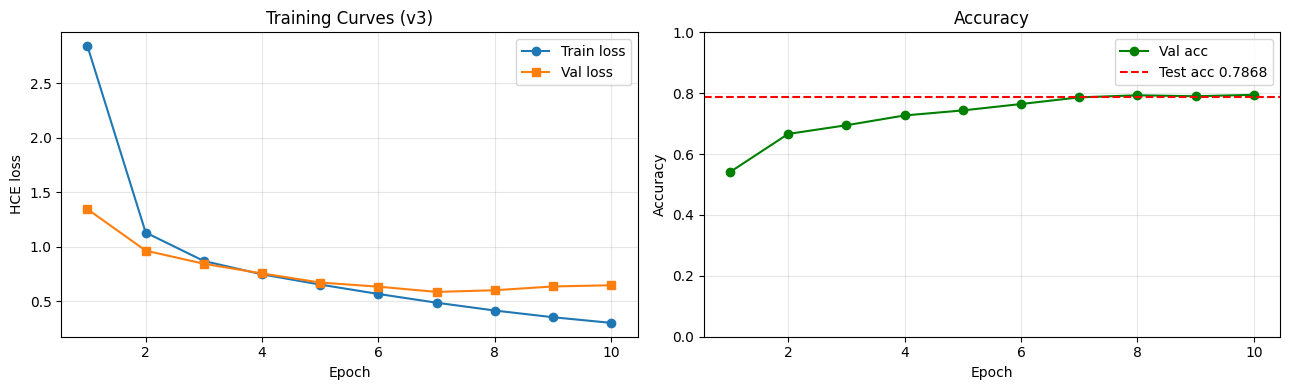

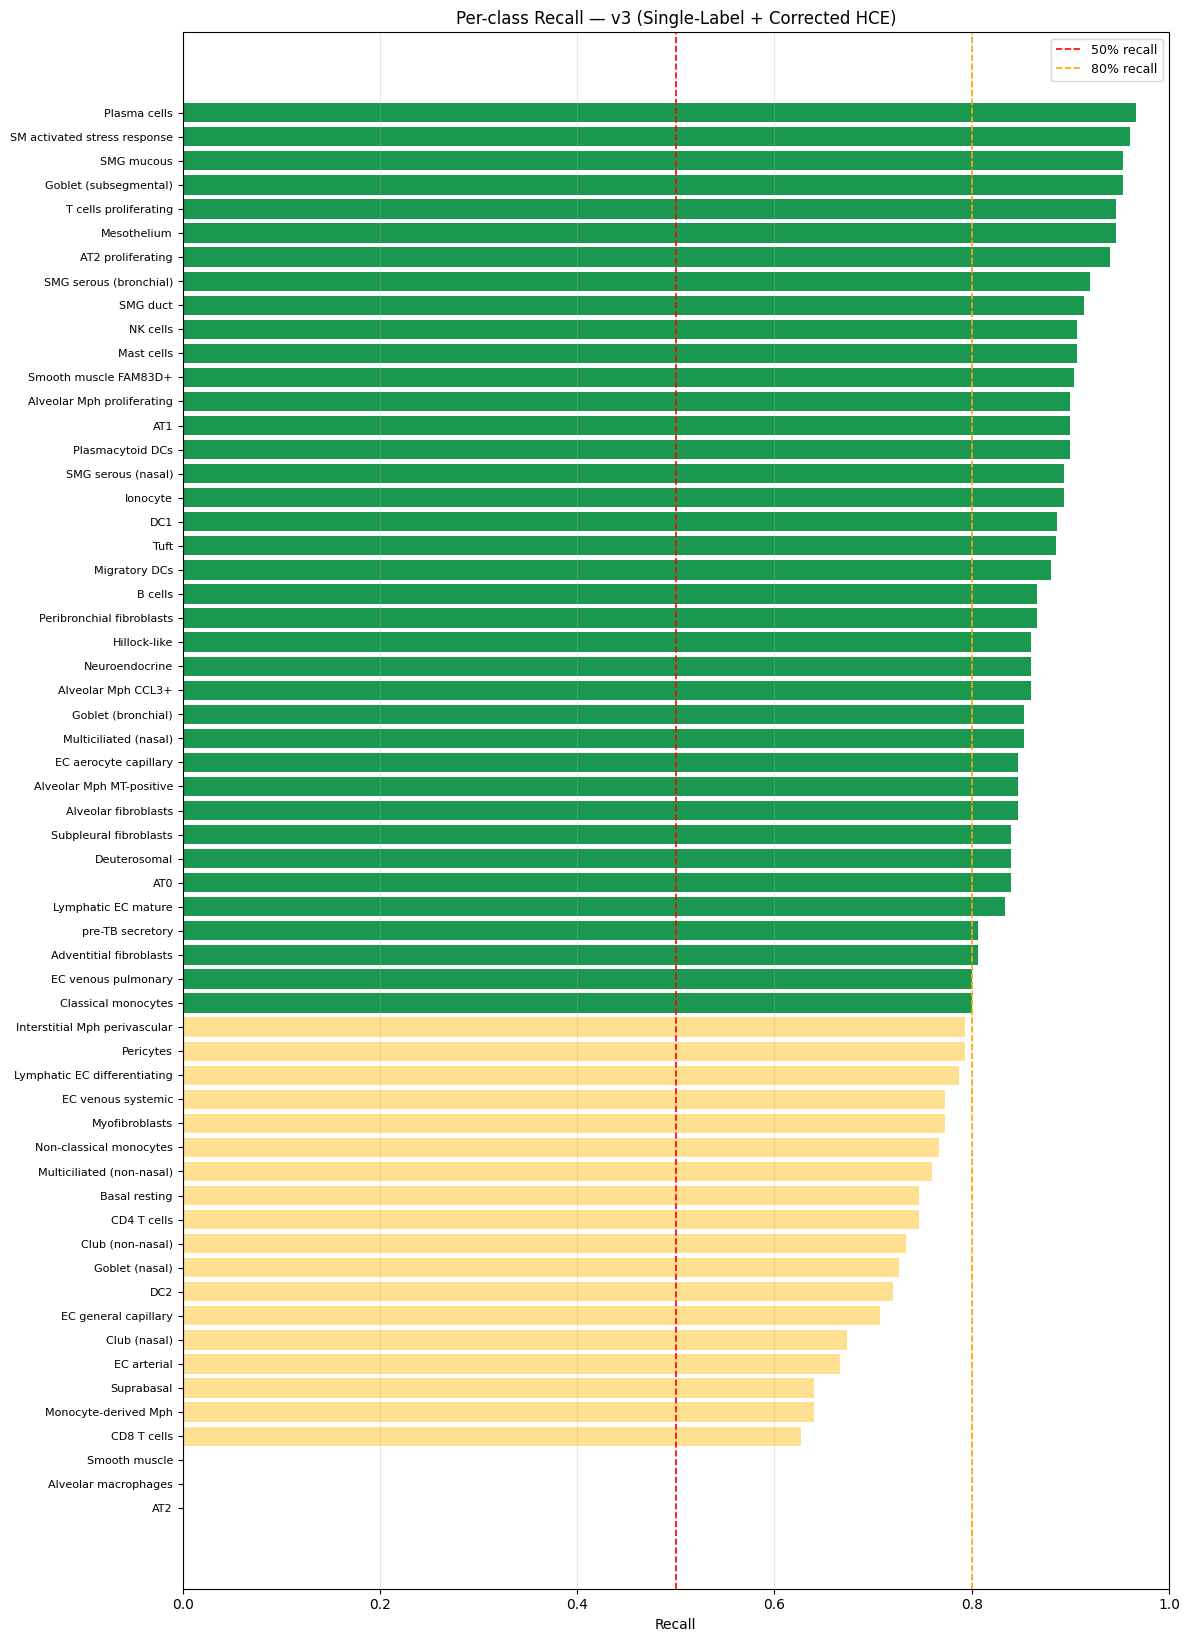

Top 20 misclassifications:
                  true_class                   pred_class  count  pct_of_true
                         AT2            AT2 proliferating    140     0.933333
               Smooth muscle SM activated stress response    103     0.686667
        Alveolar macrophages           Alveolar Mph CCL3+     72     0.480000
        Alveolar macrophages   Alveolar Mph proliferating     52     0.346667
                 CD8 T cells                     NK cells     23     0.153333
Lymphatic EC differentiating          Lymphatic EC mature     21     0.140000
               Basal resting                   Suprabasal     20     0.133333
   Multiciliated (non-nasal)        Multiciliated (nasal)     19     0.126667
         Lymphatic EC mature Lymphatic EC differentiating     19     0.126667
                Club (nasal)               Goblet (nasal)     19     0.126667
        EC general capillary                  EC arterial     19     0.126667
                  Suprabasal         

In [13]:
# Training curves
epochs_ax = np.arange(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs_ax, history['train_loss'], "o-", label="Train loss")
axes[0].plot(epochs_ax, history['val_loss'],   "s-", label="Val loss")
axes[0].set(xlabel="Epoch", ylabel="HCE loss", title="Training Curves (v3)")
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(epochs_ax, history['val_acc'], "o-", color="green", label="Val acc")
axes[1].axhline(test_acc, ls="--", color="red", label=f"Test acc {test_acc:.4f}")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy", ylim=[0, 1])
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-class recall bar chart
cm_raw  = confusion_matrix(test_trues_all, test_preds_all, labels=unique_test)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)
cm_names_test = [class_names[i] for i in unique_test]

recall_df = pd.DataFrame({
    "cell_type": cm_names_test,
    "recall":    np.diag(cm_norm),
    "n_test":    cm_raw.sum(axis=1),
}).sort_values("recall")

fig, ax = plt.subplots(figsize=(12, max(6, len(unique_test) * 0.28)))
colors = ["#d73027" if r < 0.5 else "#fee090" if r < 0.8 else "#1a9850" for r in recall_df.recall]
ax.barh(recall_df.cell_type, recall_df.recall, color=colors)
ax.axvline(0.5, color="red",    ls="--", lw=1.2, label="50% recall")
ax.axvline(0.8, color="orange", ls="--", lw=1.2, label="80% recall")
ax.set(xlabel="Recall", title="Per-class Recall — v3 (Single-Label + Corrected HCE)", xlim=[0, 1])
ax.legend(fontsize=9); ax.tick_params(axis="y", labelsize=8); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_class_recall.png"), dpi=150, bbox_inches="tight")
plt.show()

# Top misclassifications
rows_mc = []
for i, true_idx in enumerate(unique_test):
    total_true = cm_raw[i].sum()
    if total_true == 0: continue
    for j, pred_idx in enumerate(unique_test):
        if i != j and cm_raw[i, j] > 0:
            rows_mc.append({"true_class": cm_names_test[i], "pred_class": cm_names_test[j],
                            "count": int(cm_raw[i, j]), "pct_of_true": cm_raw[i, j] / total_true})
mc_df = pd.DataFrame(rows_mc).sort_values("count", ascending=False).reset_index(drop=True)
mc_df.to_csv(os.path.join(OUT_DIR, "top_misclassifications.csv"), index=False)
print("Top 20 misclassifications:")
print(mc_df.head(20).to_string(index=False))
print(f"\nRecall summary:")
dr = np.diag(cm_norm)
print(f"  Mean={dr.mean():.4f}  Median={np.median(dr):.4f}  Min={dr.min():.4f}  Max={dr.max():.4f}")
print(f"  recall < 0.5 : {(dr < 0.5).sum()}  |  recall >= 0.8 : {(dr >= 0.8).sum()}")

## 12. Summary

In [ ]:
print("=" * 60)
print("  HCE v3 TRAINING SUMMARY")
print("=" * 60)

summary = f"""
DATASET CONFIGURATION
=====================
Original dataset:       {adata.shape[0]:,} cells
Balanced dataset:       {len(cell_texts):,} cells
Max cells per type:     {MAX_CELLS_PER_TYPE}
Min cells per type:     {MIN_CELLS_PER_TYPE}
Leaf cell types:        {len(leaf_classes)}
Total logit classes:    {n_classes} (leaves + ancestors)

MODEL CONFIGURATION
===================
Encoder:                {C2S_MODEL_NAME.split('/')[-1]}
Label scheme:           Single-label (finest level — no Option A)
Loss function:          Corrected HCE (parent->child R, Floyd-Warshall, capped weights)
Optimizer:              AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})
Epochs:                 {N_EPOCHS}
Batch size:             {BATCH_SIZE}

TEST SET PERFORMANCE
====================
Test Accuracy:          {test_acc:.4f}  ({test_acc*100:.2f}%)
Macro F1:               {f1_m:.4f}
Macro Precision:        {prec_m:.4f}
Macro Recall:           {rec_m:.4f}
Classes with 0% recall: {len(per_class[per_class['recall']==0.0])}

Top 5 by F1:
"""
for _, row in per_class.head(5).iterrows():
    summary += f"  {row['cell_type']:<40s}: F1={row['f1']:.4f} (P={row['precision']:.4f}, R={row['recall']:.4f})\n"

print(summary)
with open(os.path.join(OUT_DIR, 'hce_training_summary.txt'), 'w') as f:
    f.write(summary)
print(f"[OK] Summary saved to {OUT_DIR}")

  HCE v3 TRAINING SUMMARY

DATASET CONFIGURATION
Original dataset:       2,282,447 cells
Balanced dataset:       57,522 cells
Max cells per type:     1000
Min cells per type:     100
Leaf cell types:        59
Total logit classes:    91 (leaves + ancestors)

MODEL CONFIGURATION
Encoder:                C2S-Pythia-410m-cell-type-conditioned-cell-generation
Label scheme:           Single-label (finest level — no Option A)
Loss function:          Corrected HCE (parent->child R, Floyd-Warshall, capped weights)
Optimizer:              AdamW (lr=0.0001, weight_decay=0.01)
Epochs:                 10
Batch size:             8

TEST SET PERFORMANCE
Test Accuracy:          0.7868  (78.68%)
Macro F1:               0.7716
Macro Precision:        0.7623
Macro Recall:           0.7891
Classes with 0% recall: 3

Top 5 by F1:
  SMG mucous                              : F1=0.9597 (P=0.9662, R=0.9533)
  Plasma cells                            : F1=0.9571 (P=0.9477, R=0.9667)
  T cells proliferating      

: 